In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import pandas as pd
import yaml
from scipy.signal import csd, detrend
from mpl_toolkits.mplot3d import Axes3D

In [2]:
campaign_dir = "/Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/"

# Quicklooks to check processed data

## Noseboom

### Definitions

In [3]:
def import_dictionary(yaml_file):
    try:
        with open(yaml_file, "r") as f:
            config = yaml.safe_load(f)
        return config
    except:
        print("yaml file not found or import error!!!")

In [4]:
def plot_wind_arrows(lat, lon, u, v, alt, flight,
                     track_stride=100,
                     wind_stride=1000,
                     wind_avg=500,
                     scale=0.003):

    lat_t = lat.isel(time=slice(None, None, track_stride)).values
    lon_t = lon.isel(time=slice(None, None, track_stride)).values
    alt_t = alt.isel(time=slice(None, None, track_stride)).values

    u_avg = u.rolling(time=wind_avg, center=True, min_periods=1).mean()
    v_avg = v.rolling(time=wind_avg, center=True, min_periods=1).mean()
    u_w = u_avg.isel(time=slice(None, None, wind_stride)).values
    v_w = v_avg.isel(time=slice(None, None, wind_stride)).values
    lat_w = lat.isel(time=slice(None, None, wind_stride)).values
    lon_w = lon.isel(time=slice(None, None, wind_stride)).values
    wspd = np.sqrt(u_w**2 + v_w**2)

    # --- Track as LineCollection (altitude color) ---
    points = np.array([lon_t, lat_t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm_alt = mcolors.Normalize(vmin=np.nanmin(alt_t), vmax=np.nanmax(alt_t))
    cmap_alt = plt.cm.viridis

#    lc = LineCollection(segments, cmap=cmap_alt, norm=norm_alt,
#                        linewidth=1.2, alpha=0.8, zorder=1) # without cartopy

    # --- wind arrows ---
    norm_wind = mcolors.Normalize(vmin=np.nanmin(wspd), vmax=np.nanmax(wspd))
    cmap_wind = plt.cm.plasma

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    # --- Map ---
#    ax.add_feature(cfeature.LAND,       facecolor="white")
#    ax.add_feature(cfeature.OCEAN,      facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE,  linewidth=0.5)

    # Zoomt automatisch auf den Track
    margin = 0.5  # Grad
    get_extent_square(ax, lon_t, lat_t)
    ax.set_extent([lon_t.min()-margin, lon_t.max()+margin,
                   lat_t.min()-margin, lat_t.max()+margin])

    # --- Track (transform immer angeben!) ---
    lc = LineCollection(segments, cmap=cmap_alt, norm=norm_alt,
                        linewidth=1.5, alpha=0.8, zorder=2,
                        transform=ccrs.PlateCarree())
    lc.set_array(alt_t[:-1])
    ax.add_collection(lc)

    mask = np.isfinite(u_w) & np.isfinite(v_w)
    for i in np.where(mask)[0]:
        color = cmap_wind(norm_wind(wspd[i]))
        ax.annotate("",
            xy=(lon_w[i] + u_w[i]*scale, lat_w[i] + v_w[i]*scale),
            xytext=(lon_w[i], lat_w[i]),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=1.2))

    # --- Colorbars ---
    sm_alt = plt.cm.ScalarMappable(cmap=cmap_alt, norm=norm_alt)
    sm_alt.set_array([])
    cbar_alt = plt.colorbar(sm_alt, ax=ax, shrink=0.6, pad=0.02)
    cbar_alt.set_label("altitude (m)")

    sm_wind = plt.cm.ScalarMappable(cmap=cmap_wind, norm=norm_wind)
    sm_wind.set_array([])
    cbar_wind = plt.colorbar(sm_wind, ax=ax, shrink=0.6, pad=0.10)
    cbar_wind.set_label("horizontal wind speed (m/s)")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels   = False  # only bottom and left
    gl.right_labels = False
    ax.autoscale()

    ax.text(0.5, -0.1, "longitude", transform=ax.transAxes,
            ha="center", fontsize=11)
    ax.text(-0.1, 0.5, "latitude", transform=ax.transAxes,
            ha="center", rotation=90, fontsize=11)
    ax.set_aspect("equal")
    ax.set_title(f"BACSAM II RF{flight:02}: flight track with wind")
    plt.tight_layout()
    plt.show()
    return fig, ax

In [309]:
def plot_wind_arrows_3d(lat, lon, u, v, w, alt, flight,
                        track_stride=100,
                        wind_stride=1000,
                        wind_avg=500,
                        scale=0.003,
                        scale_z=1.0):   # Pfeile vertikal skalieren

    lat_t = lat.isel(time=slice(None, None, track_stride)).values
    lon_t = lon.isel(time=slice(None, None, track_stride)).values
    alt_t = alt.isel(time=slice(None, None, track_stride)).values

    u_avg = u.rolling(time=wind_avg, center=True, min_periods=1).mean()
    v_avg = v.rolling(time=wind_avg, center=True, min_periods=1).mean()
    w_avg = w.rolling(time=wind_avg, center=True, min_periods=1).mean()
    u_w = u_avg.isel(time=slice(None, None, wind_stride)).values
    v_w = v_avg.isel(time=slice(None, None, wind_stride)).values
    w_w = w_avg.isel(time=slice(None, None, wind_stride)).values
    lat_w = lat.isel(time=slice(None, None, wind_stride)).values
    lon_w = lon.isel(time=slice(None, None, wind_stride)).values
    alt_w = alt.isel(time=slice(None, None, wind_stride)).values
    wspd = np.sqrt(u_w**2 + v_w**2 + w_w**2)

    norm_alt  = mcolors.Normalize(vmin=np.nanmin(alt_t), vmax=np.nanmax(alt_t))
    norm_wind = mcolors.Normalize(vmin=np.nanmin(wspd),  vmax=np.nanmax(wspd))
    cmap_alt  = plt.cm.viridis
    cmap_wind = plt.cm.plasma

    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection='3d')

    # --- Track (Segmente einzeln für Höhenfärbung) ---
    for i in range(len(lon_t) - 1):
        avg_alt = 0.5 * (alt_t[i] + alt_t[i+1])
        color   = cmap_alt(norm_alt(avg_alt))
        ax.plot(lon_t[i:i+2], lat_t[i:i+2], alt_t[i:i+2],
                color=color, linewidth=1.0, alpha=0.8)

    # --- Windpfeile als quiver ---
    mask = np.isfinite(u_w) & np.isfinite(v_w)
    colors_wind = [cmap_wind(norm_wind(ws)) for ws in wspd[mask]]

    ax.quiver(lon_w[mask], lat_w[mask], alt_w[mask],
              u_w[mask] * scale, v_w[mask] * scale, w_w[mask] * scale,
              colors=colors_wind,
              arrow_length_ratio=0.0,
              linewidth=1.5)

#    # Pfeilspitzen als Scatter-Punkte am Pfeilende
#    lon_end = lon_w[mask] + u_w[mask] * scale
#    lat_end = lat_w[mask] + v_w[mask] * scale
#    alt_end = alt_w[mask] + w_w[mask] * scale_z
    
#    ax.scatter(lon_end, lat_end, alt_end,
#               c=wspd[mask], cmap=cmap_wind, norm=norm_wind,
#               s=20, zorder=5, depthshade=True)
    
    # --- Colorbars (als separate Axes) ---
    sm_alt = plt.cm.ScalarMappable(cmap=cmap_alt, norm=norm_alt)
    sm_alt.set_array([])
    plt.colorbar(sm_alt, ax=ax, shrink=0.5, pad=0.1, label="Höhe (m)")

    sm_wind = plt.cm.ScalarMappable(cmap=cmap_wind, norm=norm_wind)
    sm_wind.set_array([])
    plt.colorbar(sm_wind, ax=ax, shrink=0.5, pad=0.15, label="wind speed (m/s)")

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_zlabel("altitude (m)")
    ax.set_title(f"BACSAM II RF{flight:02}: 3D flight track with wind")
    plt.tight_layout()
    plt.show()
    return fig, ax

### Plots

In [5]:
compare2joerg = True

no calibration segments during this flight


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/1924307033.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


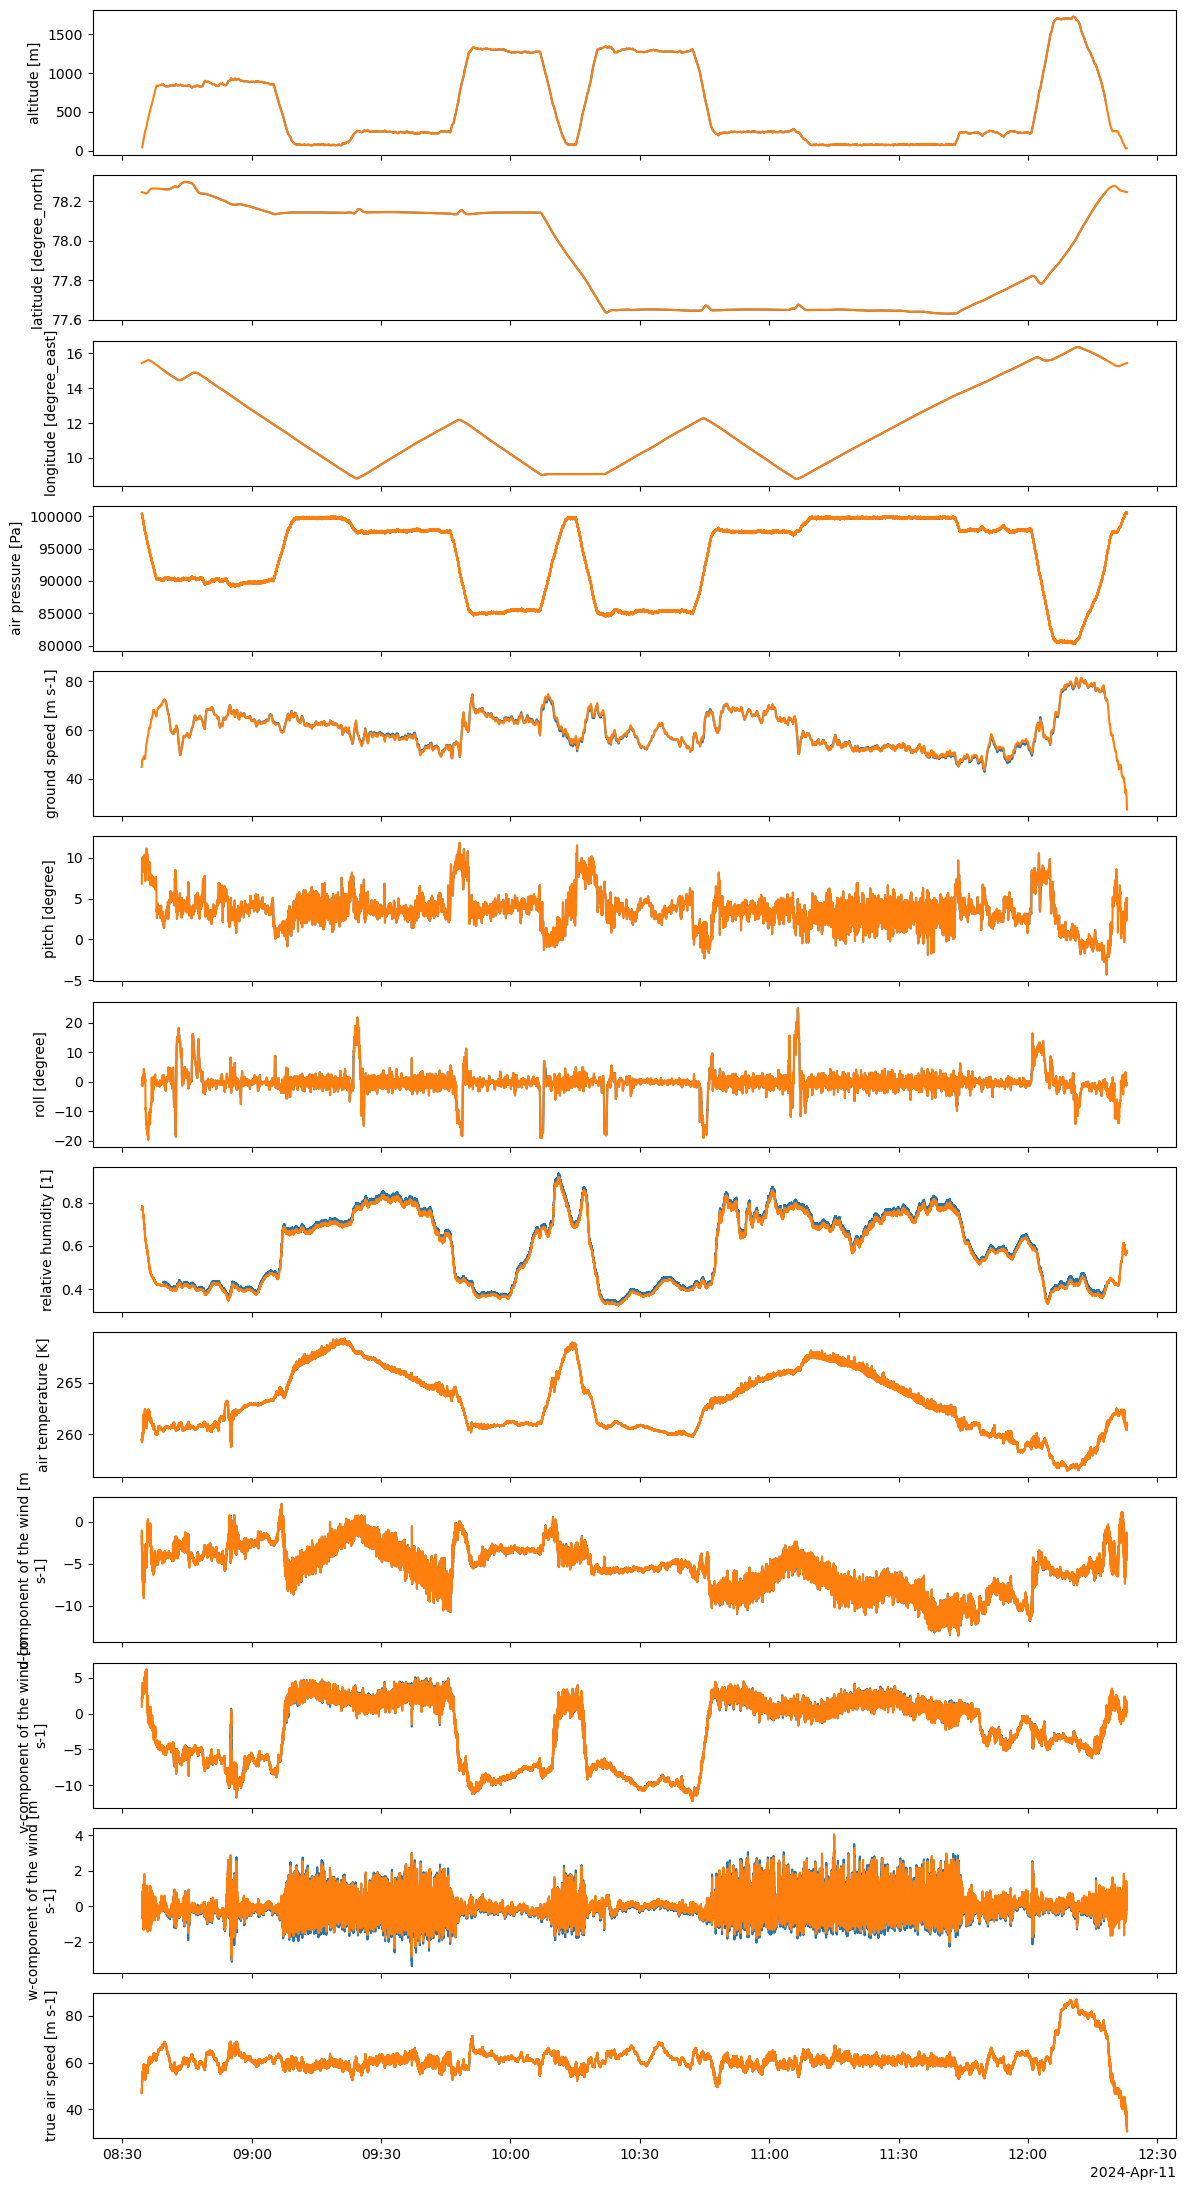

In [167]:
flight = 3
config_fn = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml"
config = import_dictionary(config_fn)

try:
    cal_segs = config["flights"][flight]["calibration"]
except:
    print("no calibration segments during this flight")
    cal_segs = {}

flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

date = date_dict[flight]
flight_joerg = flightnumber_dict[flight]

fn = f"{campaign_dir}/Prozessierung/noseboom/BACSAM2_{date}_RF{flight:02}_noseboom_100Hz.nc"
#fn = f"/Users/lakoeh001/AWI/Campaigns/20260103SANAT/Daten/Prozessierung/SANAT_{date}_RF{flight:02}_noseboom_100Hz.nc"
proc = xr.open_dataset(fn)

if compare2joerg:
    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz.asc"
    with open(file, "r") as f:
        first_line = f.readline().strip()
    
    colnames = first_line[1:].split() 
    data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)
    times = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_jeorg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")
    data_100hz = data_jeorg
    data_100hz["time"] = times
    
    ref = data_100hz.set_index("time").to_xarray()

fig, axs = plt.subplots(13,1,figsize=(12,22),sharex=True)

if compare2joerg:
    varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 'rh':'rh', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}
    for v, ax in zip(list(proc.keys()), fig.get_axes()):
        if v == "rh":
            data2plot = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            data2plot = ref[varnames_joerg[v]] + 273.15
        elif v == "p_air":
            data2plot = ref[varnames_joerg[v]] *100
        else:
            data2plot = ref[varnames_joerg[v]]
        data2plot.sel(time = slice(proc.time.min() + np.timedelta64(5,"m"),proc.time.max() - np.timedelta64(5,"m"))).plot(ax = ax)

for v, ax in zip(list(proc.keys()), fig.get_axes()):
    proc[v].plot(ax = ax)
    ax.set_xlabel("")

for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

plt.tight_layout()

#plt.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_noseboom_RF{flight:02}.png")

In [32]:
flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

for flight in [1, 2, 3, 40, 41, 42, 5, 6, 7, 8, 9, 10, 11]:
    date = date_dict[flight]
    flight_joerg = flightnumber_dict[flight]

    fn = f"{campaign_dir}/Prozessierung/noseboom/BACSAM2_{date}_RF{flight:02}_noseboom_100Hz.nc"
    proc = xr.open_dataset(fn)

    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz.asc"
    with open(file, "r") as f:
        colnames = f.readline().strip()[1:].split()

    # Only read needed columns
    needed = ["UTC", "u", "v", "w"]
    usecols = [colnames.index(c) for c in needed]
    data_joerg = pd.read_csv(file, sep=r"\s+", comment="!", header=None,
                             usecols=usecols, names=needed, engine="c")

    # Faster time conversion
    base = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}", "ns")
    times = (np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_joerg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")).astype("datetime64[ns]")

    # Build xarray directly without going through pandas index
    ref = None
    ref = xr.Dataset(
        {v: ("time", data_joerg[v].values) for v in ["u", "v", "w"]},
        coords={"time": times}
    )
#    ref = ref.sel(time=slice(proc.time.min(), proc.time.max()))
    ref["w"] = ref.w - ref.w.mean()
    ref = ref.interp(time=proc.time)

    print(f"RF{flight:02}:")
    for v in ["u", "v", "w"]:
        diff = (proc[v] - ref[v]).sel(time = slice(proc.time.min() + np.timedelta64(5,"m"), proc.time.max() - np.timedelta64(5,"m"))).values
        mask = np.isfinite(diff)
        diff = diff[mask]
        bias = diff.mean()
        mae  = np.abs(diff).mean()
        rmse = np.sqrt((diff**2).mean())
        print(f"    {v}: bias = {bias:.4f} m/s, mae = {mae:.4f} m/s, rmse = {rmse:.4f} m/s")

RF01:
    u: bias = 0.0015 m/s, mae = 0.0361 m/s, rmse = 0.0492 m/s
    v: bias = -0.0003 m/s, mae = 0.0455 m/s, rmse = 0.0592 m/s
    w: bias = -0.0166 m/s, mae = 0.0273 m/s, rmse = 0.0390 m/s
RF02:
    u: bias = -0.0006 m/s, mae = 0.0608 m/s, rmse = 0.0779 m/s
    v: bias = 0.0000 m/s, mae = 0.0248 m/s, rmse = 0.0350 m/s
    w: bias = -0.0327 m/s, mae = 0.0427 m/s, rmse = 0.0553 m/s
RF03:
    u: bias = 0.0004 m/s, mae = 0.0324 m/s, rmse = 0.0488 m/s
    v: bias = -0.0050 m/s, mae = 0.0788 m/s, rmse = 0.1092 m/s
    w: bias = -0.0367 m/s, mae = 0.0697 m/s, rmse = 0.0978 m/s
RF40:
    u: bias = 0.0469 m/s, mae = 0.0493 m/s, rmse = 0.0564 m/s
    v: bias = 0.0458 m/s, mae = 0.0499 m/s, rmse = 0.0579 m/s
    w: bias = -0.0473 m/s, mae = 0.0491 m/s, rmse = 0.0546 m/s
RF41:
    u: bias = -0.0000 m/s, mae = 0.0461 m/s, rmse = 0.0552 m/s
    v: bias = 0.0000 m/s, mae = 0.0172 m/s, rmse = 0.0228 m/s
    w: bias = -0.0199 m/s, mae = 0.0273 m/s, rmse = 0.0350 m/s
RF42:
    u: bias = -0.0462 m/s

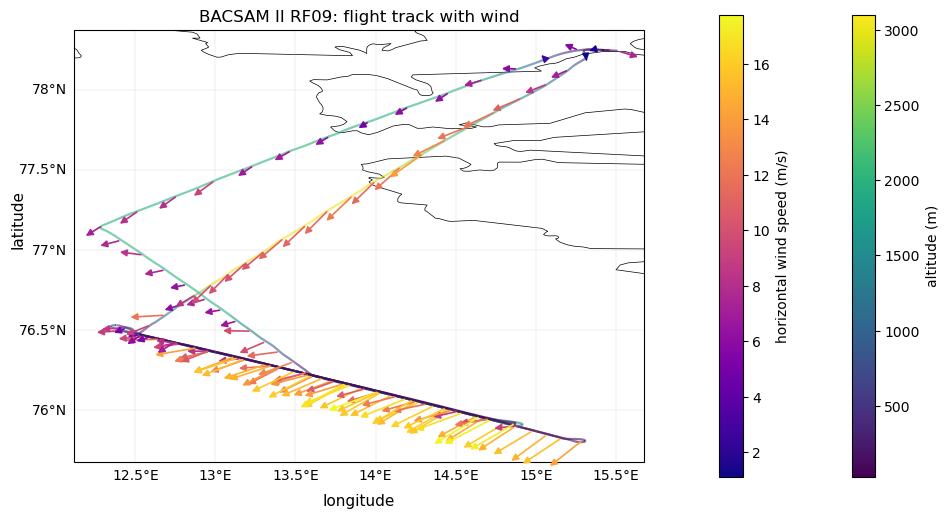

In [388]:
fig, ax = plot_wind_arrows(proc.lat, proc.lon, proc.u, proc.v, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.02)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_noseboom_RF{flight:02}.png", bbox_inches='tight')

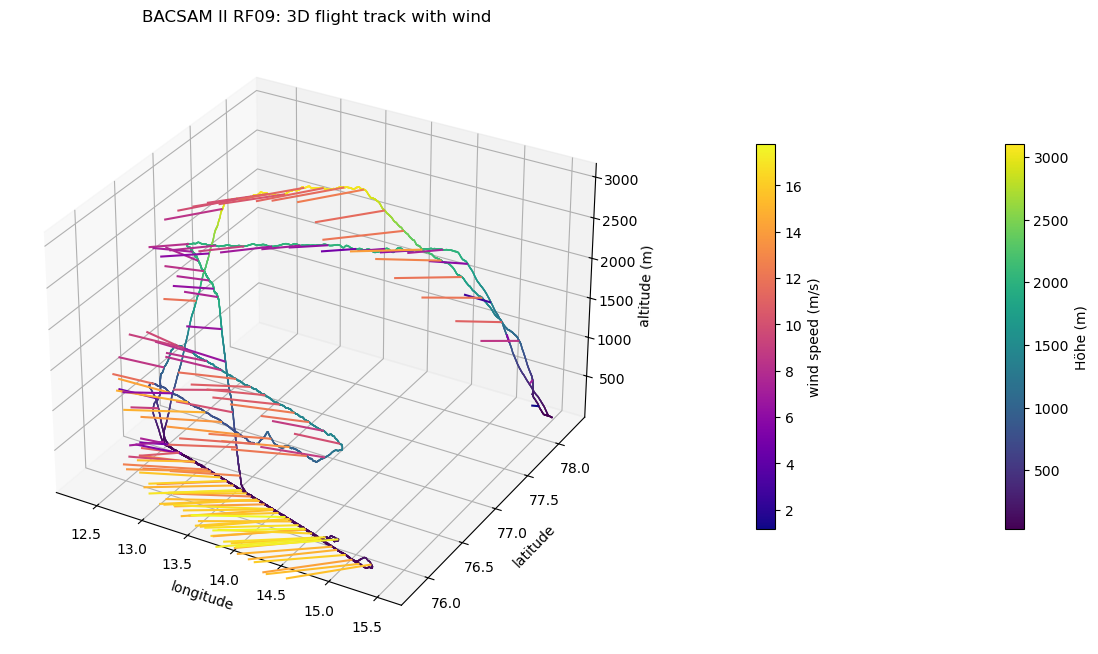

In [389]:
fig, ax = plot_wind_arrows_3d(proc.lat, proc.lon, proc.u, proc.v, proc.w, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.05)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_3d_noseboom_RF{flight:02}.png", bbox_inches='tight')

## T-Bird

In [83]:
compare2joerg = True

no calibration segments during this flight


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/2194644727.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


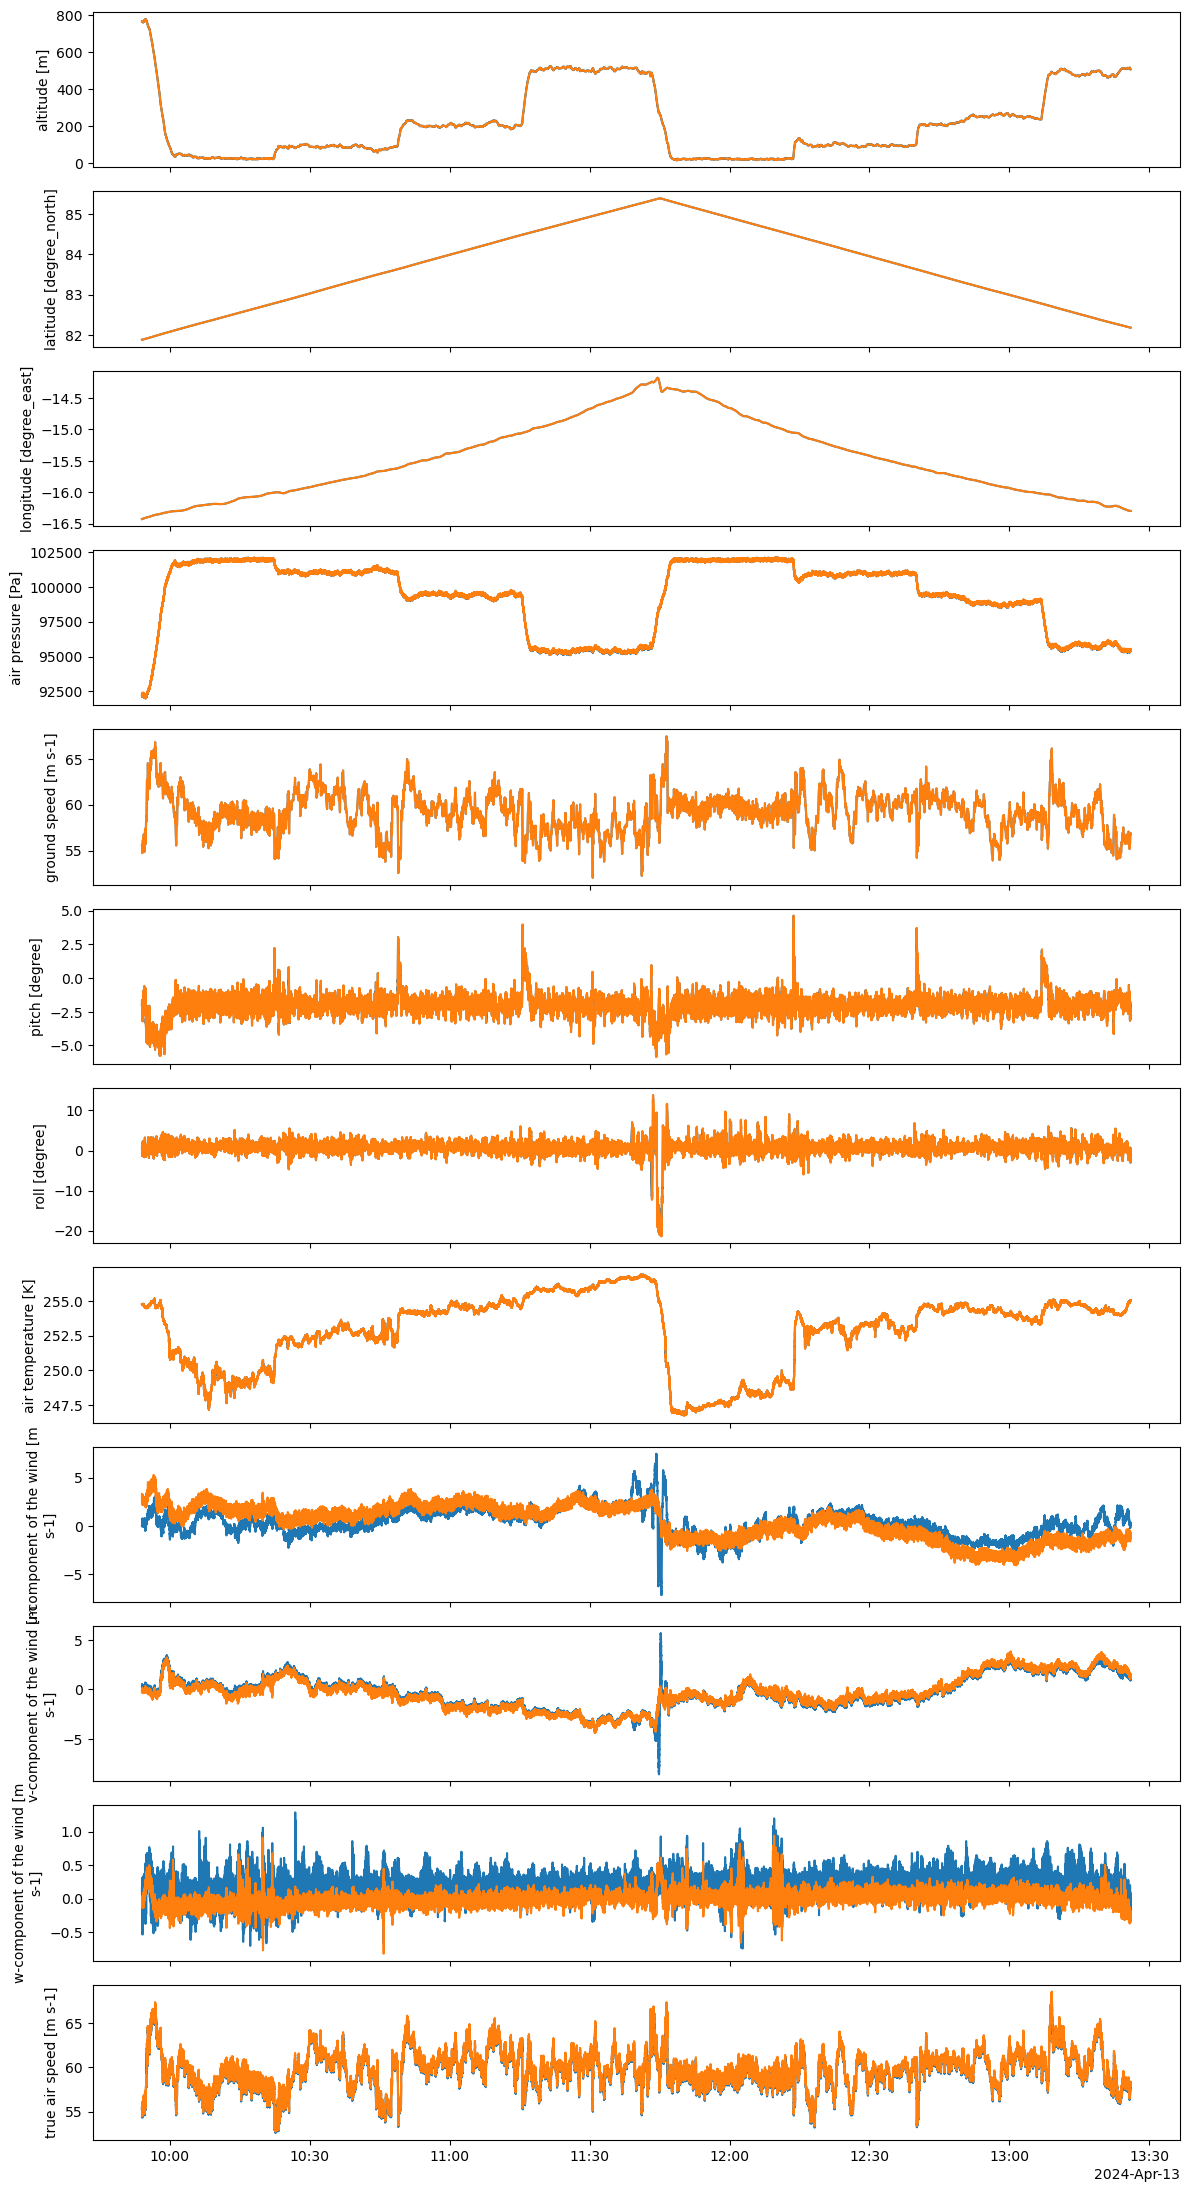

In [84]:
flight = 41
config_fn = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml"
config = import_dictionary(config_fn)

flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

date = date_dict[flight]
flight_joerg = flightnumber_dict[flight]

fn = f"{campaign_dir}/Prozessierung/tbird/BACSAM2_{date}_RF{flight:02}_tbird_100Hz.nc"
proc = xr.open_dataset(fn)

try:
    cal_segs = config["flights"][flight]["calibration"]
except:
    print("no calibration segments during this flight")
    cal_segs = {}

for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

if compare2joerg:
    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz_tb.asc"
    with open(file, "r") as f:
        first_line = f.readline().strip()
    
    colnames = first_line[1:].split() 
    data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)
    times = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_jeorg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")
    data_100hz = data_jeorg
    data_100hz["time"] = times
    
    ref = data_100hz.set_index("time").to_xarray()

fig, axs = plt.subplots(12,1,figsize=(12,22),sharex=True)

if compare2joerg:
    varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}
    for v, ax in zip(list(proc.keys()), fig.get_axes()):
        if v == "rh":
            data2plot = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            data2plot = ref[varnames_joerg[v]] + 273.15 
        elif v == "p_air":
            data2plot = ref[varnames_joerg[v]] *100
        else:
            data2plot = ref[varnames_joerg[v]]
        data2plot.sel(time = slice(proc.time.min(),proc.time.max())).plot(ax = ax)

for v, ax in zip(list(proc.keys()), fig.get_axes()):
    proc[v].plot(ax = ax)
    ax.set_xlabel("")

for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

plt.tight_layout()

#plt.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_tbird_RF{flight:02}.png")

In [146]:
flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

for flight in [41, 5, 6, 7, 9]:
    date = date_dict[flight]
    flight_joerg = flightnumber_dict[flight]

    fn = f"{campaign_dir}/Prozessierung/tbird/BACSAM2_{date}_RF{flight:02}_tbird_100Hz.nc"
    proc = xr.open_dataset(fn)

    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz_tb.asc"
    with open(file, "r") as f:
        colnames = f.readline().strip()[1:].split()

    # Only read needed columns
    needed = ["UTC", "u", "v", "w"]
    usecols = [colnames.index(c) for c in needed]
    data_joerg = pd.read_csv(file, sep=r"\s+", comment="!", header=None,
                             usecols=usecols, names=needed, engine="c")
    

    # Faster time conversion
    base = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}", "ns")
    times = (np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_joerg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")).astype("datetime64[ns]")

    # Build xarray directly without going through pandas index
    ref = None
    ref = xr.Dataset(
        {v: ("time", data_joerg[v].values) for v in ["u", "v", "w"]},
        coords={"time": times}
    )
#    ref = ref.sel(time=slice(proc.time.min(), proc.time.max()))
    ref["w"] = ref.w - ref.w.mean()
    ref = ref.interp(time=proc.time)

    print(f"RF{flight:02}:")
    for v in ["u", "v", "w"]:
        diff = (proc[v] - ref[v]).sel(time = slice(proc.time.min() + np.timedelta64(5,"m"), proc.time.max() - np.timedelta64(5,"m"))).values
        mask = np.isfinite(diff)
        diff = diff[mask]
        bias = diff.mean()
        mae  = np.abs(diff).mean()
        rmse = np.sqrt((diff**2).mean())
        print(f"    {v}: bias = {bias:.4f} m/s, mae = {mae:.4f} m/s, rmse = {rmse:.4f} m/s")

RF41:
    u: bias = 0.0380 m/s, mae = 1.0479 m/s, rmse = 1.2740 m/s
    v: bias = 0.0015 m/s, mae = 0.2160 m/s, rmse = 0.3896 m/s
    w: bias = -0.0143 m/s, mae = 0.0553 m/s, rmse = 0.0812 m/s
RF05:
    u: bias = -0.0003 m/s, mae = 1.0092 m/s, rmse = 1.1202 m/s
    v: bias = -0.0370 m/s, mae = 0.2169 m/s, rmse = 0.2816 m/s
    w: bias = 0.0035 m/s, mae = 0.0760 m/s, rmse = 0.1186 m/s
RF06:
    u: bias = -0.1804 m/s, mae = 0.6462 m/s, rmse = 0.8066 m/s
    v: bias = 0.0564 m/s, mae = 0.9763 m/s, rmse = 1.1484 m/s
    w: bias = -0.0006 m/s, mae = 0.0933 m/s, rmse = 0.1442 m/s
RF07:
    u: bias = -0.1632 m/s, mae = 0.3646 m/s, rmse = 0.5628 m/s
    v: bias = 0.0147 m/s, mae = 1.0508 m/s, rmse = 1.3008 m/s
    w: bias = 0.0003 m/s, mae = 0.3886 m/s, rmse = 0.5299 m/s
RF09:
    u: bias = 0.1077 m/s, mae = 1.1130 m/s, rmse = 1.3958 m/s
    v: bias = -0.1834 m/s, mae = 0.9408 m/s, rmse = 1.2076 m/s
    w: bias = -0.0024 m/s, mae = 0.1205 m/s, rmse = 0.1691 m/s


In [166]:
flightnumber_dict = {1: 1, 2: 2, 3: 3, 40: 4, 41: 5, 42: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13}
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}
varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}

for flight in [41, 5, 6, 7, 9]:
    date = date_dict[flight]
    flight_joerg = flightnumber_dict[flight]

    fn = f"{campaign_dir}/Prozessierung/tbird/BACSAM2_{date}_RF{flight:02}_tbird_100Hz.nc"
    proc = xr.open_dataset(fn)

    file = f"{campaign_dir}/Turbulenz/Met_100Hz_Polar6_TB/Flight_{date}_P6_{flight_joerg:02}_100Hz_tb.asc"
    with open(file, "r") as f:
        first_line = f.readline().strip()
    
    colnames = first_line[1:].split() 
    data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)
    times = (np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_jeorg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")).astype("datetime64[ns]")
    data_100hz = data_jeorg
    data_100hz["time"] = times
    
    ref = data_100hz.set_index("time").to_xarray()

    ref = ref.interp(time=proc.time)
    # Only read needed columns
#    needed = ["UTC", "T", "p"]
#    usecols = [colnames.index(c) for c in needed]
#    data_joerg = pd.read_csv(file, sep=r"\s+", comment="!", header=None,
#                             names=needed, engine="c")

    # Faster time conversion
#    base = np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}", "ns")
#    times = (np.datetime64(f"{date[:4]}-{date[4:6]}-{date[6:]}") + (data_joerg["UTC"].values * 1e3).astype("int64") * np.timedelta64(1, "ms")).astype("datetime64[ns]")

    # Build xarray directly without going through pandas index
#    ref = None
#    ref = xr.Dataset(
#        {v: ("time", data_joerg[v].values) for v in ["T", "p"]},
#        coords={"time": times}
#    )
    print(f"RF{flight:02}:")
    for v in ["t_air", "p_air"]:
        if v == "rh":
            ref[varnames_joerg[v]] = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            ref[varnames_joerg[v]] = ref[varnames_joerg[v]] + 273.15 
        elif v == "p_air":
            ref[varnames_joerg[v]] = ref[varnames_joerg[v]] *100
        diff = (proc[v] - ref[varnames_joerg[v]]).sel(time = slice(proc.time.min() + np.timedelta64(5,"m"), proc.time.max() - np.timedelta64(5,"m"))).values
        mask = np.isfinite(diff)
        diff = diff[mask]
        bias = diff.mean()
        mae  = np.abs(diff).mean()
        rmse = np.sqrt((diff**2).mean())
        print(f"    {v}: bias = {bias:.4f} unit, mae = {mae:.4f} unit, rmse = {rmse:.4f} unit")

/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/487601771.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


RF41:
    t_air: bias = -0.0058 unit, mae = 0.0058 unit, rmse = 0.0065 unit
    p_air: bias = 9.2404 unit, mae = 10.0332 unit, rmse = 13.6508 unit


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/487601771.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


RF05:
    t_air: bias = -0.0058 unit, mae = 0.0058 unit, rmse = 0.0065 unit
    p_air: bias = 4.4288 unit, mae = 6.0854 unit, rmse = 9.1641 unit


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/487601771.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


RF06:
    t_air: bias = -0.0064 unit, mae = 0.0064 unit, rmse = 0.0070 unit
    p_air: bias = 6.3119 unit, mae = 9.2433 unit, rmse = 12.5899 unit


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/487601771.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


RF07:
    t_air: bias = -0.0064 unit, mae = 0.0064 unit, rmse = 0.0070 unit
    p_air: bias = 7.0606 unit, mae = 9.9019 unit, rmse = 13.3731 unit


/var/folders/j4/fclf6j0x39j3cnr71ql3kg0r4jskdr/T/ipykernel_24061/487601771.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_jeorg = pd.read_csv(file,delim_whitespace=True, comment="!", names=colnames,)


RF09:
    t_air: bias = -0.0068 unit, mae = 0.0068 unit, rmse = 0.0074 unit
    p_air: bias = 4.1187 unit, mae = 6.6306 unit, rmse = 10.1631 unit


In [77]:
deviations = {"u": [], "v": [], "w": []}

for flight in [9]:
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    date = date_dict[flight]
    fn_out = f"{campaign_dir}/Prozessierung/tbird/BACSAM2_{date}_RF{flight:02}_tbird_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    cal_segments = config["flights"][flight]["calibration"]
    num = int(len(cal_segments)/2 + 1)
    if flight == 8:                                                                             # BACSAM 2
        calibs = np.arange(2,num)
    else:
        calibs = np.arange(1,num)
    for j in calibs:
        out_proc = data_proc.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
        ret_proc = data_proc.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))

        out_vhor = np.sqrt(out_proc.u**2 + out_proc.v**2)
        ret_vhor = np.sqrt(ret_proc.u**2 + ret_proc.v**2)
        for v in ["u", "v", "w"]:
            out_mean = out_proc[v].mean().values
            out_se   = out_proc[v].std() / np.sqrt(out_proc.sizes["time"])
            ret_mean = ret_proc[v].mean().values
            ret_se   = ret_proc[v].std() / np.sqrt(ret_proc.sizes["time"])
            mean_speed = (out_mean + ret_mean)/2
            dev = (out_mean - ret_mean)/2
            deviations[v].append(dev)
            percent = dev/mean_speed
            print(f"{v}: out= {out_mean:.4f}, out_std = {out_se:.4f}, ret = {ret_mean:.4f}, ret_std = {ret_se:.4f}, mean = {mean_speed:.4f}, dev = {dev:.4f}")

u: out= -13.6173, out_std = 0.0045, ret = -12.5538, ret_std = 0.0043, mean = -13.0855, dev = -0.5317
v: out= -8.2724, out_std = 0.0035, ret = -6.9586, ret_std = 0.0044, mean = -7.6155, dev = -0.6569
w: out= -0.0023, out_std = 0.0022, ret = 0.0118, ret_std = 0.0022, mean = 0.0048, dev = -0.0071
u: out= -14.9346, out_std = 0.0043, ret = -13.4374, ret_std = 0.0043, mean = -14.1860, dev = -0.7486
v: out= -7.1870, out_std = 0.0040, ret = -6.3581, ret_std = 0.0049, mean = -6.7726, dev = -0.4145
w: out= -0.0170, out_std = 0.0025, ret = 0.0222, ret_std = 0.0025, mean = 0.0026, dev = -0.0196


In [78]:
deviations

{'u': [-0.5317406503159301, -0.7485926492325383],
 'v': [-0.6568989184920371, -0.4144755493047172],
 'w': [-0.007077579685252522, -0.019645547901269034]}

In [79]:
np.std(deviations["u"], ddof=1)

0.15333751894779152

In [80]:
np.std(deviations["v"], ddof=1)

0.17141920827044382

In [81]:
np.std(deviations["w"], ddof=1)

0.008886895551282272

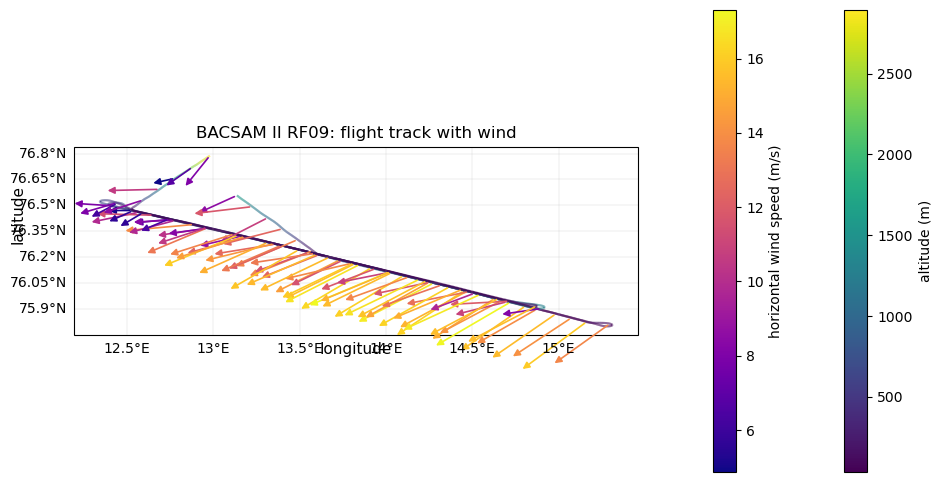

In [418]:
fig, ax = plot_wind_arrows(proc.lat, proc.lon, proc.u, proc.v, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.03)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_tbird_RF{flight:02}.png", bbox_inches='tight')

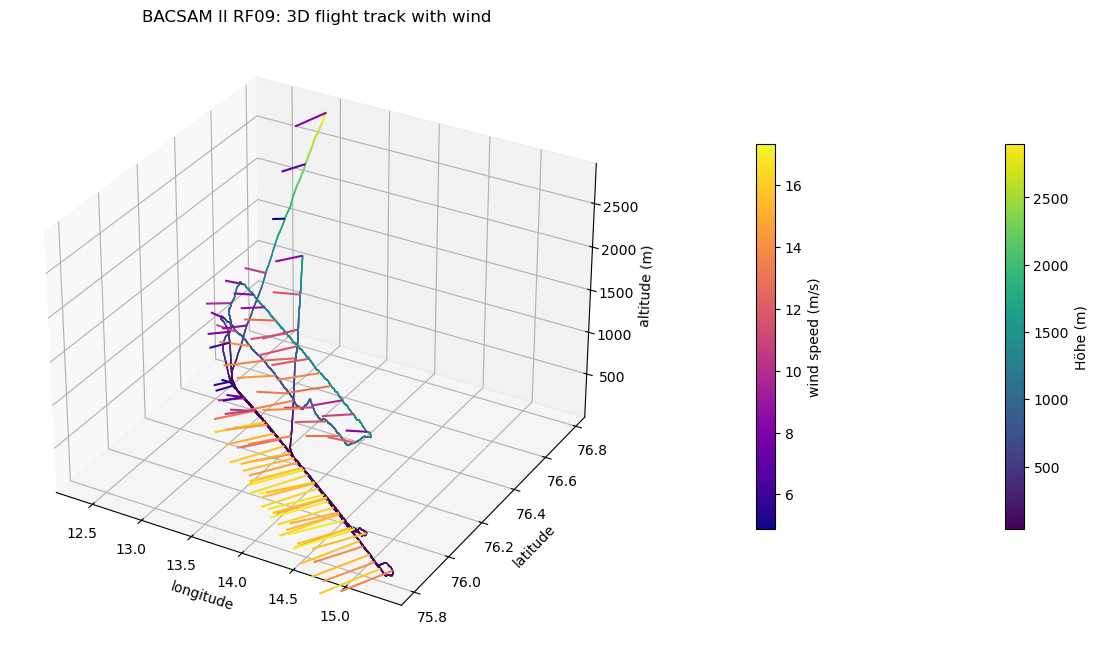

In [419]:
fig, ax = plot_wind_arrows_3d(proc.lat, proc.lon, proc.u, proc.v, proc.w, proc.alt, flight,
                           track_stride=100,   # every 1 s a track point
                           wind_stride=12000,   # draw every 2 min an arrow
                           wind_avg=1000,       # 10s average
                           scale=0.02)        # Arrow scale (adjust)

#fig.savefig(f"{campaign_dir}/Prozessierung/plots/BACSAM2_windontrack_3d_tbird_RF{flight:02}.png", bbox_inches='tight')

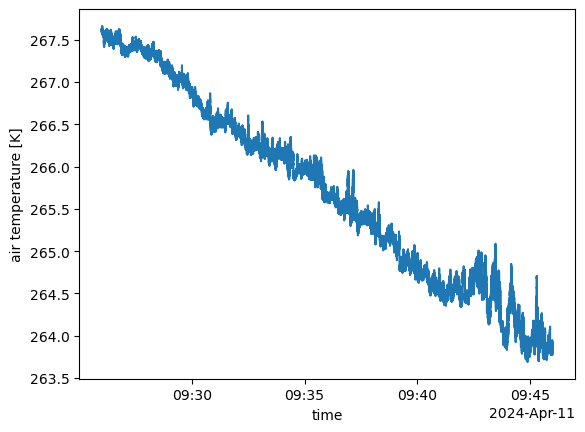

In [176]:
proc.groupby("segment")[5].t_air.plot()

## pdfs

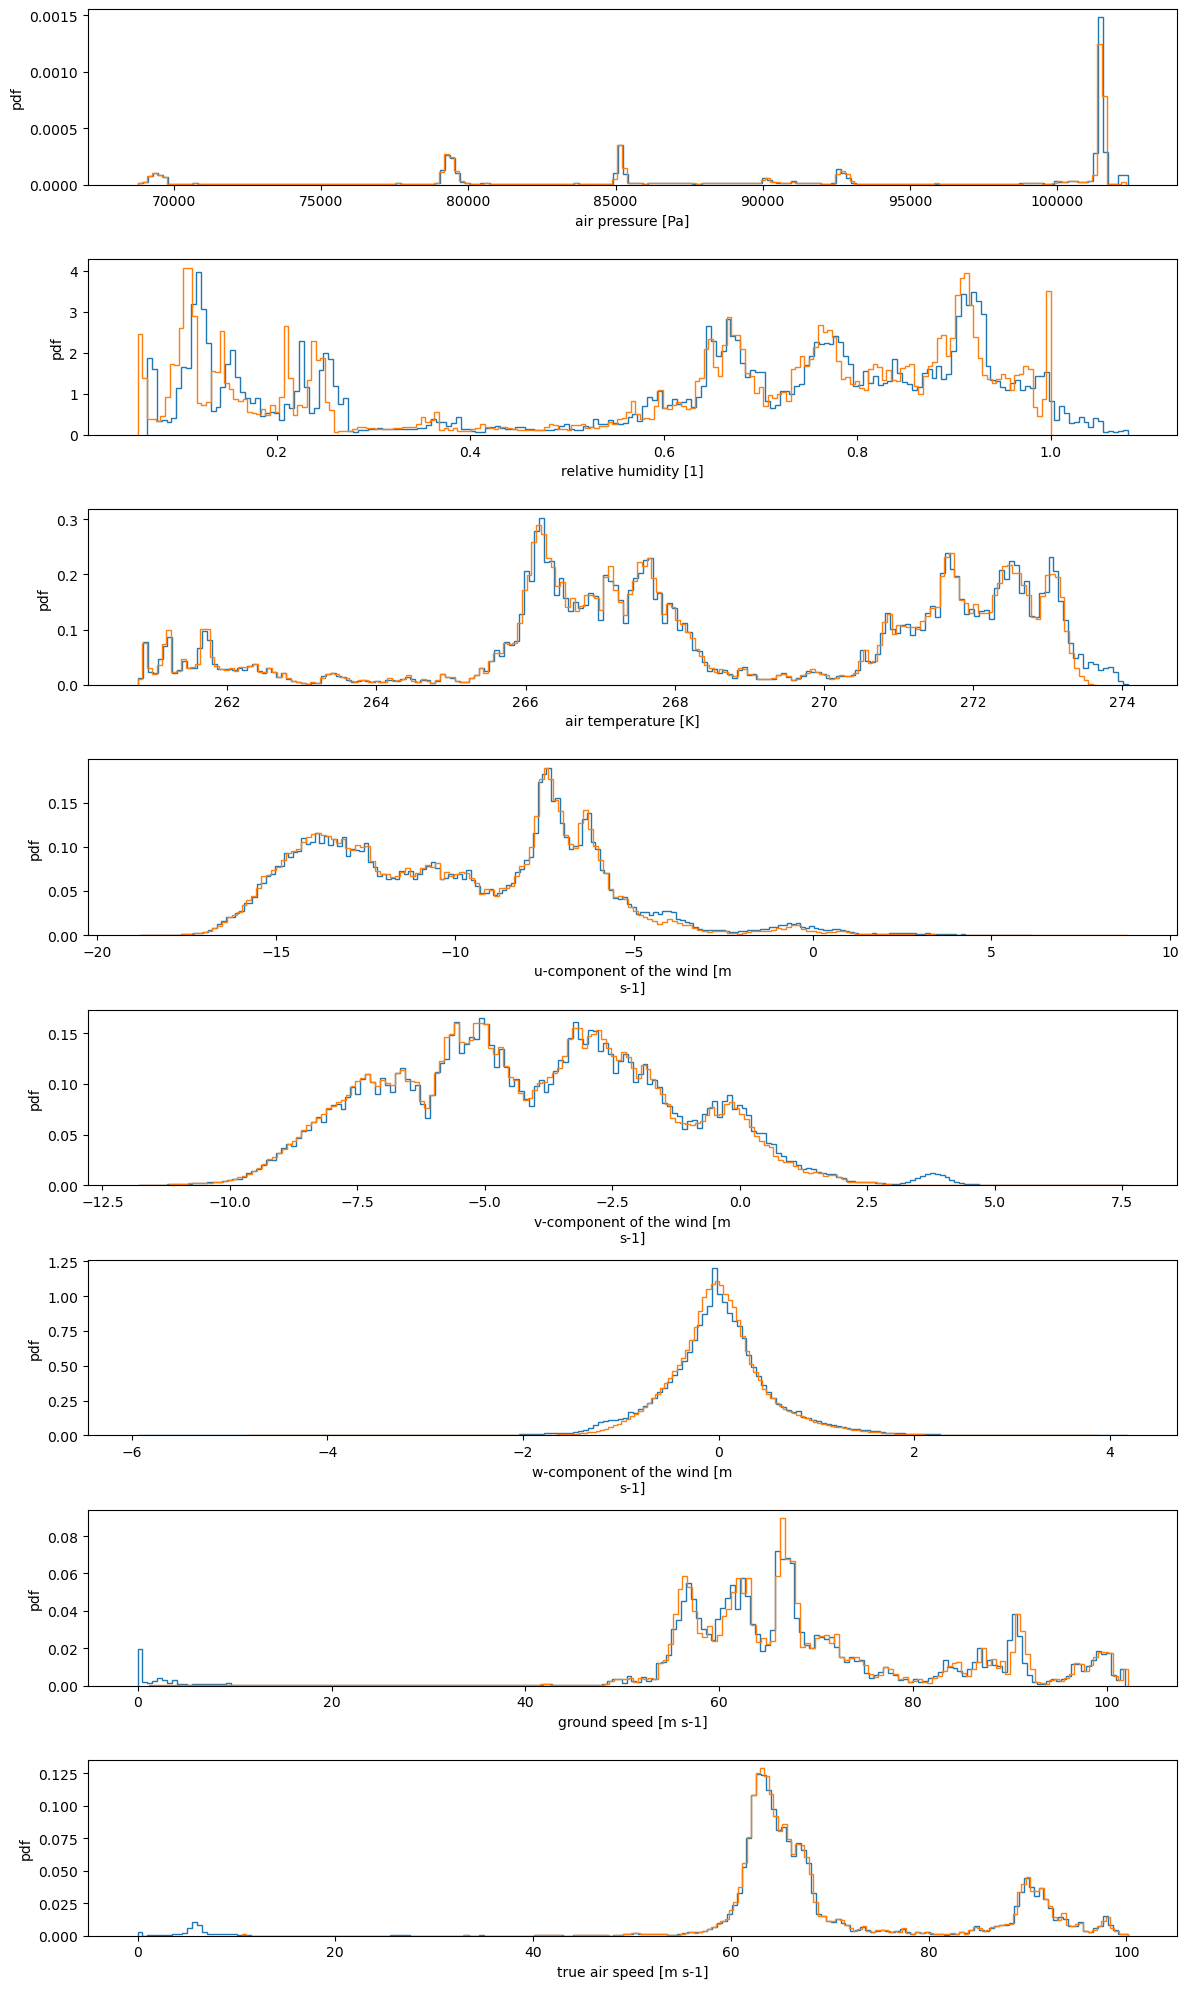

In [73]:
fig, axs = plt.subplots(8,1,figsize=(12,20))

pdf_vars = ['p_air', 'rh', 't_air', 'u', 'v', 'w', 'gs', 'taspd']

if compare2joerg:
    varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 'rh':'rh', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}
    for v, ax in zip(pdf_vars, fig.get_axes()):
        if v == "rh":
            data2plot = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            data2plot = ref[varnames_joerg[v]] + 273.15
        elif v == "p_air":
            data2plot = ref[varnames_joerg[v]] *100
        else:
            data2plot = ref[varnames_joerg[v]]
        xr.plot.hist(data2plot, bins = 200, density = True, histtype='step', ax = ax)

for v, ax in zip(pdf_vars, fig.get_axes()):
    xr.plot.hist(proc[v], bins = 200, density = True, histtype='step', ax = ax)
    ax.set_ylabel("pdf")

plt.tight_layout()

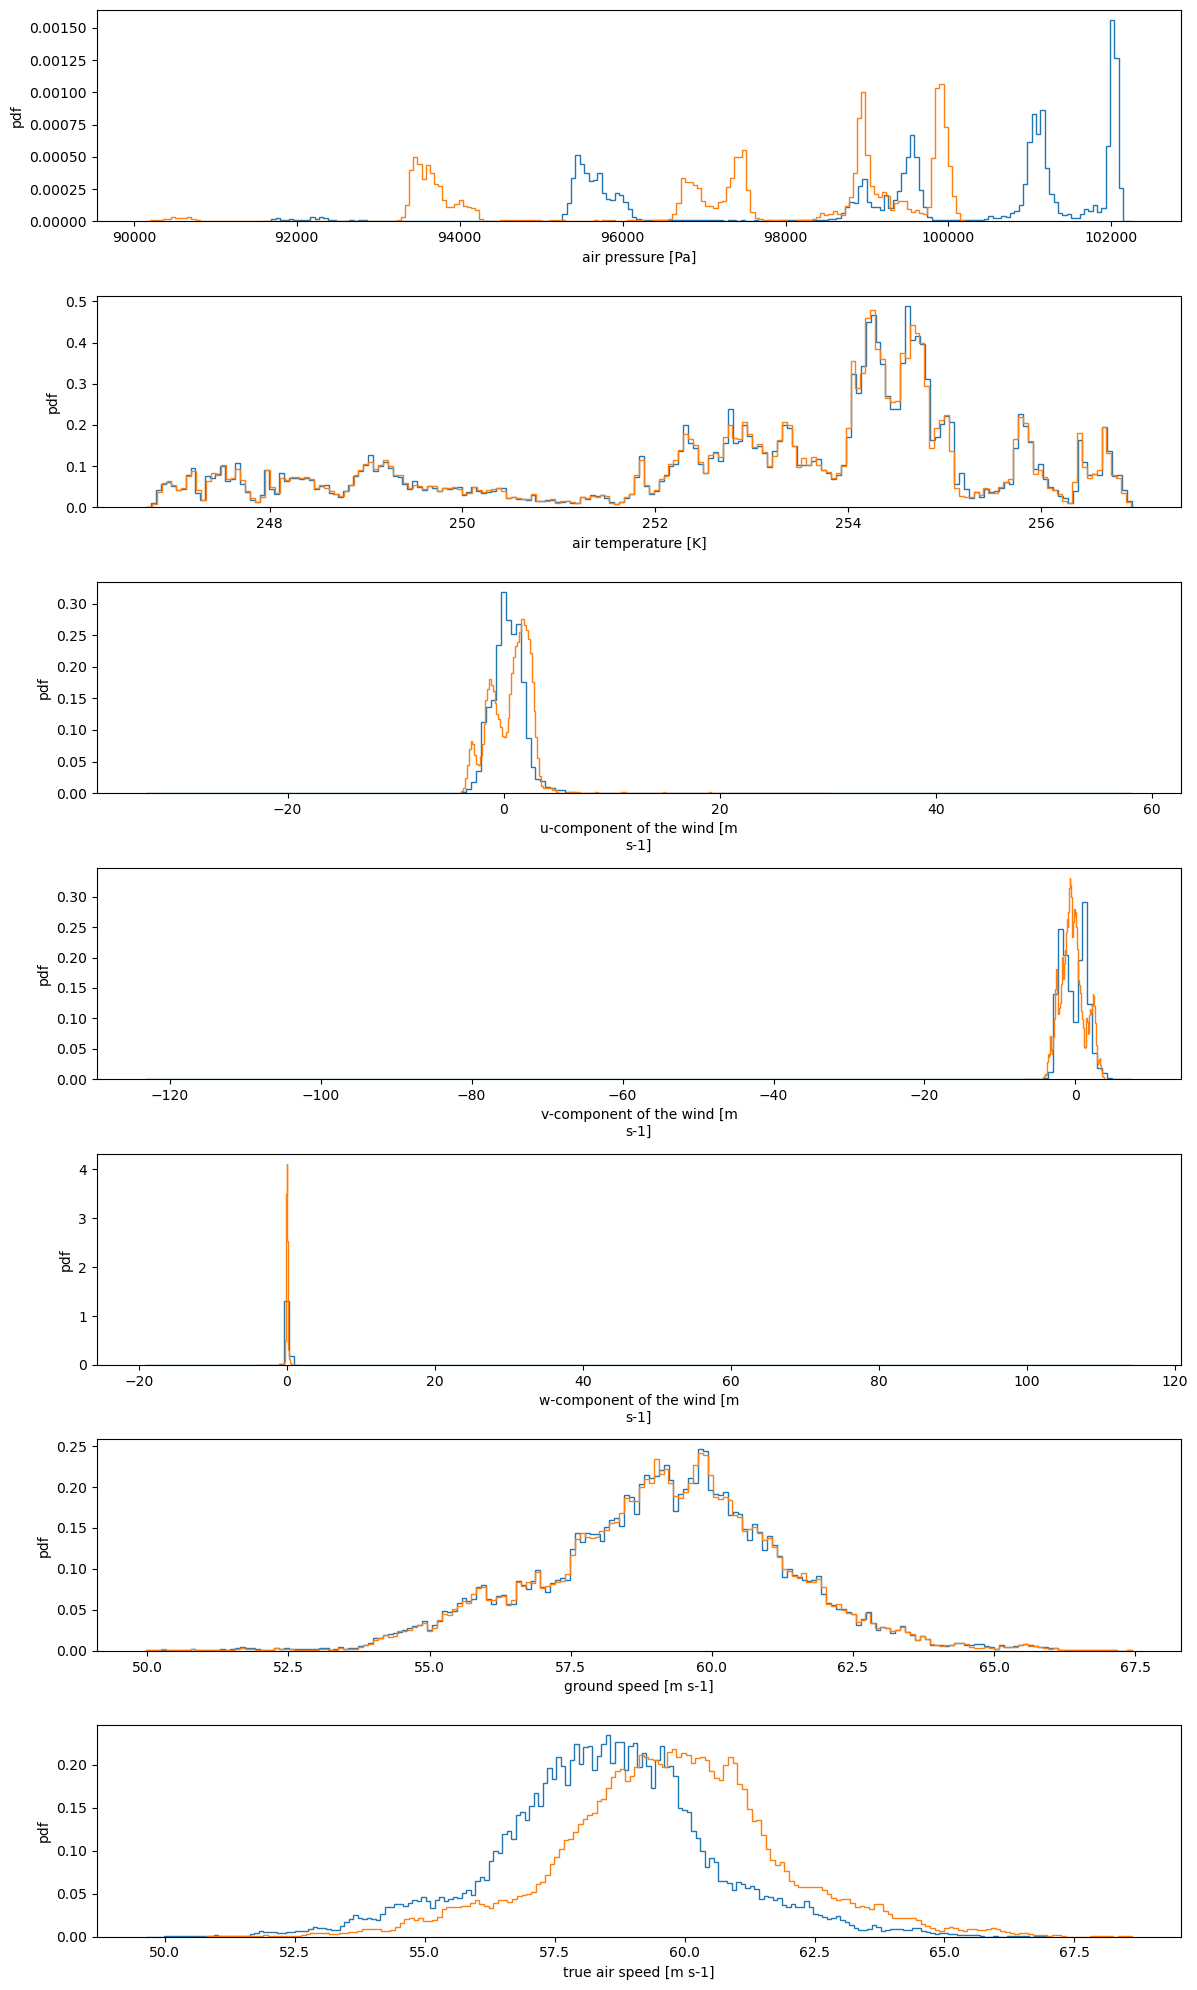

In [148]:
# T-Bird
fig, axs = plt.subplots(7,1,figsize=(12,20))

pdf_vars = ['p_air', 't_air', 'u', 'v', 'w', 'gs', 'taspd']

if compare2joerg:
    varnames_joerg = { 'alt': 'h', 'lat': 'lat', 'lon':'lon', 'p_air':'p', 'gs':'gs', 'pitch':'pitch', 'roll':'roll', 'rh':'rh', 't_air': 'T', 'u':'u', 'v': 'v', 'w':'w', 'taspd':'tas'}
    for v, ax in zip(pdf_vars, fig.get_axes()):
        if v == "rh":
            data2plot = ref[varnames_joerg[v]] /100
        elif v == "t_air":
            data2plot = ref[varnames_joerg[v]] + 273.15
        elif v == "p_air":
            data2plot = ref[varnames_joerg[v]] *100
        else:
            data2plot = ref[varnames_joerg[v]]
        xr.plot.hist(data2plot, bins = 200, density = True, histtype='step', ax = ax)

for v, ax in zip(pdf_vars, fig.get_axes()):
    xr.plot.hist(proc[v], bins = 200, density = True, histtype='step', ax = ax)
    ax.set_ylabel("pdf")

plt.tight_layout()

## Export csv file

For sharing data 1 Hz csv files might be useful. Here is the code to create them.

In [273]:
campaign_name = config["campaign"]["name"]
outdir = "/Users/lakoeh001/AWI/Campaigns/20260103SANAT/Daten/Prozessierung"

'20260129'

In [274]:
sec = proc.resample(time = "1s").mean()
df = sec.to_dataframe()

In [276]:
df.to_csv(f"{outdir}/{campaign_name}_{date}_RF{flight:02}_1Hz.csv")

# Spectra

## Power spectral density of w and T

Compute the power spectrum over single flight segments.

In [72]:
flight = 9
config_fn = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml"
config = import_dictionary(config_fn)

date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

date = date_dict[flight]

fn = f"{campaign_dir}/Prozessierung/noseboom/BACSAM2_{date}_RF{flight:02}_noseboom_100Hz.nc"
proc = xr.open_dataset(fn)

In [74]:
legs = proc.groupby("segment")

### Welch spectrum

In [59]:
from scipy.signal import welch, detrend

def welch_spectrum(da, fs, nperseg=None):
    """
    Compute Welch power spectrum with linear detrending.

    Parameters
    ----------
    da : xarray.DataArray
        1D time series
    fs : float
        Sampling frequency [Hz]
    nperseg : int, optional
        Length of each Welch segment

    Returns
    -------
    f : np.ndarray
        Frequencies [Hz]
    Pxx : np.ndarray
        Power spectral density
    """
    x = da.values
    x = x[np.isfinite(x)]

    # linear detrend
    x = detrend(x, type="linear")

    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        detrend=False,   # already detrended
        scaling="density"
    )

    return f[1:], Pxx[1:]  # remove zero frequency

In [66]:
fs = 100.0          # Hz
nperseg = 2024      # ~10 s at 100 Hz

fw, Pw = welch_spectrum(wprime, fs)
fT, PT = welch_spectrum(Tprime, fs)

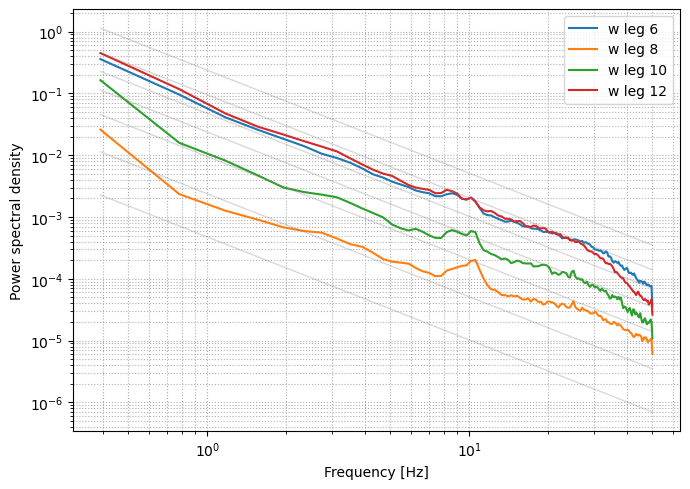

In [93]:
fs = 100.0   
nperseg = None#2024 

plt.figure(figsize=(7, 5))

for i in [6,8,10,12]:
    leg = legs[i]
    wprime = leg.w - leg.w.mean()
    fw, Pw = welch_spectrum(wprime, fs, nperseg)
    plt.loglog(fw, Pw, label = f"w leg {i}")
#    Tprime = leg.t_air - leg.t_air.mean()

#plt.loglog(fw, Pw, label="w (vertical wind)")
#plt.loglog(fT, PT, label="T (temperature)")

# Frequency range for reference slopes
f_ref = np.logspace(np.log10(fw.min()), np.log10(fw.max()), 100)

# Choose a reference level (anchor in inertial subrange)
f0 = 1.0  # Hz, choose where spectrum looks inertial
P0 = Pw[np.argmin(np.abs(fw - f0))]

# Vertical offsets for background lines
offsets = [0.01, 0.05, 0.2, 0.5, 1, 2, 5]

for fac in offsets:
    plt.loglog(
        f_ref,
        fac * P0 * (f_ref / f0) ** (-5/3),
        color="gray",
        alpha=0.3,
        linewidth=1
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power spectral density")
plt.legend()
plt.grid(True, which="both", linestyle=":")
#plt.xlim(0.2,50)

plt.tight_layout()
plt.show()

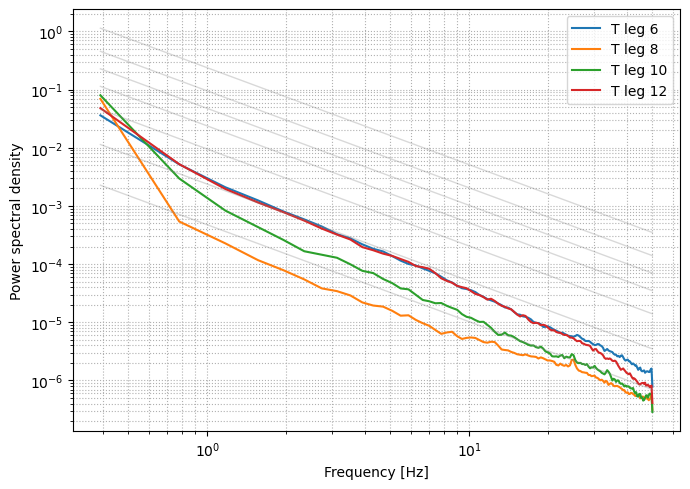

In [80]:
fs = 100.0   
nperseg = None#2024 

plt.figure(figsize=(7, 5))

for i in [6,8,10,12]:
    leg = legs[i]
    Tprime = leg.t_air - leg.t_air.mean()
    fT, PT = welch_spectrum(Tprime, fs)
    plt.loglog(fT, PT, label = f"T leg {i}")

f_ref = np.logspace(np.log10(fw.min()), np.log10(fw.max()), 100)

# Choose a reference level (anchor in inertial subrange)
f0 = 1.0  # Hz, choose where spectrum looks inertial
P0 = Pw[np.argmin(np.abs(fw - f0))]

# Vertical offsets for background lines
offsets = [0.01, 0.05, 0.2, 0.5, 1, 2, 5]

for fac in offsets:
    plt.loglog(
        f_ref,
        fac * P0 * (f_ref / f0) ** (-5/3),
        color="gray",
        alpha=0.3,
        linewidth=1
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power spectral density")
plt.legend()
plt.grid(True, which="both", linestyle=":")
#plt.xlim(0.2,50)

plt.tight_layout()
plt.show()

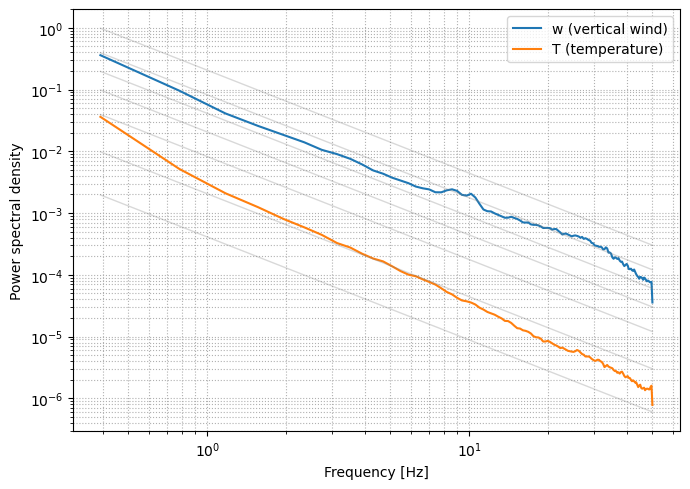

In [88]:
fs = 100.0          # Hz
nperseg = 2024      # ~10 s at 100 Hz
leg = legs[6]


wprime = leg.w - leg.w.mean()
Tprime = leg.t_air - leg.t_air.mean()

fw, Pw = welch_spectrum(wprime, fs)
fT, PT = welch_spectrum(Tprime, fs)

plt.figure(figsize=(7, 5))

plt.loglog(fw, Pw, label="w (vertical wind)")
plt.loglog(fT, PT, label="T (temperature)")

# Frequency range for reference slopes
f_ref = np.logspace(np.log10(fw.min()), np.log10(fw.max()), 100)

# Choose a reference level (anchor in inertial subrange)
f0 = 1.0  # Hz, choose where spectrum looks inertial
P0 = Pw[np.argmin(np.abs(fw - f0))]

# Vertical offsets for background lines
offsets = [0.01, 0.05, 0.2, 0.5, 1, 2, 5]

for fac in offsets:
    plt.loglog(
        f_ref,
        fac * P0 * (f_ref / f0) ** (-5/3),
        color="gray",
        alpha=0.3,
        linewidth=1
    )

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power spectral density")
plt.legend()
plt.grid(True, which="both", linestyle=":")
#plt.xlim(0.2,50)

plt.tight_layout()
plt.show()


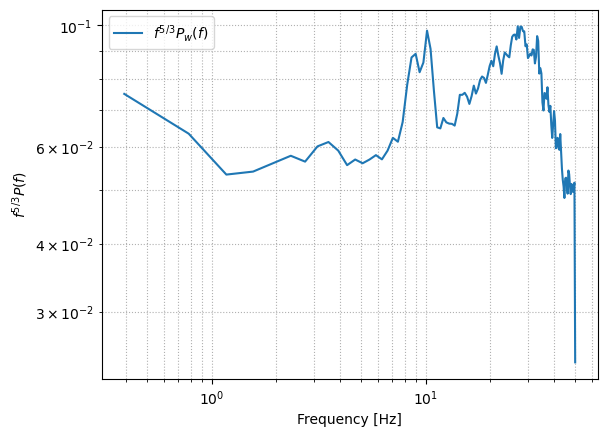

In [95]:
# Removing the 5/3 slope

leg = legs[6]
wprime = leg.w - leg.w.mean()
fw, Pw = welch_spectrum(wprime, fs)

plt.loglog(fw, fw**(5/3) * Pw, label=r"$f^{5/3} P_w(f)$")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$f^{5/3} P(f)$")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.show()

### Power spectrum

In [89]:
def power_spectrum(da, fs):
    """
    Compute 1D power spectrum of an xarray DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        1D time series
    fs : float
        Sampling frequency [Hz]

    Returns
    -------
    f : np.ndarray
        Frequencies
    Pxx : np.ndarray
        Power spectral density
    """
    x = da.values
    x = x - np.nanmean(x)

    n = len(x)
    fft = np.fft.rfft(x)
    Pxx = (np.abs(fft) ** 2) / (n * fs)
    f = np.fft.rfftfreq(n, d=1/fs)

    return f[1:], Pxx[1:]  # remove zero frequency


In [90]:
fs = 100.0  # Hz

fw, Pw = power_spectrum(leg.w, fs)
fT, PT = power_spectrum(leg.t_air, fs)


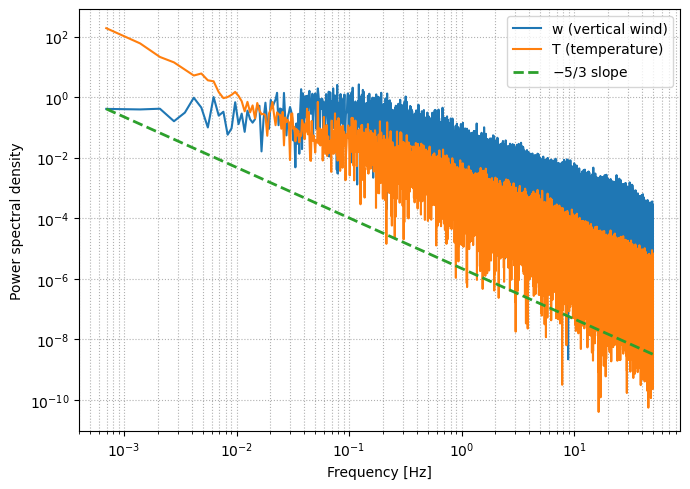

In [91]:
plt.figure(figsize=(7, 5))

plt.loglog(fw, Pw, label="w (vertical wind)")
plt.loglog(fT, PT, label="T (temperature)")

# Reference -5/3 slope
f_ref = np.array([fw.min(), fw.max()])
P_ref = Pw[0] * (f_ref / f_ref[0]) ** (-5/3)

plt.loglog(
    f_ref, P_ref,
    linestyle="--",
    linewidth=2,
    label=r"$-5/3$ slope"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power spectral density")
plt.legend()
plt.grid(True, which="both", linestyle=":")

plt.tight_layout()
plt.show()


### Heat flux

In [96]:
def fluctuations(da):
    """
    Remove mean and linear trend.
    """
    x = da.values
    x = detrend(x, type="linear")
    return x


In [97]:
def sensible_heat_flux(w, T):
    """
    Compute kinematic sensible heat flux w'T'.

    Parameters
    ----------
    w : xarray.DataArray
        Vertical wind [m s-1]
    T : xarray.DataArray
        Temperature [K or °C]

    Returns
    -------
    wt : float
        Mean kinematic heat flux [K m s-1]
    """
    w_prime = fluctuations(w)
    T_prime = fluctuations(T)

    wt = np.nanmean(w_prime * T_prime)
    return wt


In [98]:
wt = sensible_heat_flux(leg.w, leg.t_air)
print(f"Kinematic sensible heat flux w'T' = {wt:.3e} K m s-1")


Kinematic sensible heat flux w'T' = 5.390e-02 K m s-1


In [99]:
def sensible_heat_flux_physical(wt, rho=1.225, cp=1004):
    """
    Convert kinematic heat flux to sensible heat flux.

    Parameters
    ----------
    wt : float
        Kinematic heat flux [K m s-1]
    rho : float
        Air density [kg m-3]
    cp : float
        Specific heat at constant pressure [J kg-1 K-1]

    Returns
    -------
    H : float
        Sensible heat flux [W m-2]
    """
    return rho * cp * wt


In [100]:
H = sensible_heat_flux_physical(wt)
print(f"Sensible heat flux H = {H:.2f} W m-2")


Sensible heat flux H = 66.29 W m-2


In [101]:
def fluctuations(da):
    return detrend(da.values, type="linear")


In [102]:
def running_covariance(w, T, fs, window):
    """
    Running covariance <w'T'>

    Parameters
    ----------
    w, T : xarray.DataArray
    fs : float
        Sampling frequency [Hz]
    window : float
        Window length [s]
    """
    n = int(window * fs)

    cov = np.full(len(w), np.nan)

    w_fluc = fluctuations(w)
    T_fluc = fluctuations(T)

    for i in range(n//2, len(w) - n//2):
        w_seg = w_fluc[i-n//2:i+n//2]
        T_seg = T_fluc[i-n//2:i+n//2]
        cov[i] = np.mean(w_seg * T_seg)

    return xr.DataArray(cov, coords=w.coords, dims=w.dims)


In [103]:
cov_wT = running_covariance(leg.w, leg.t_air, fs=100, window=30)


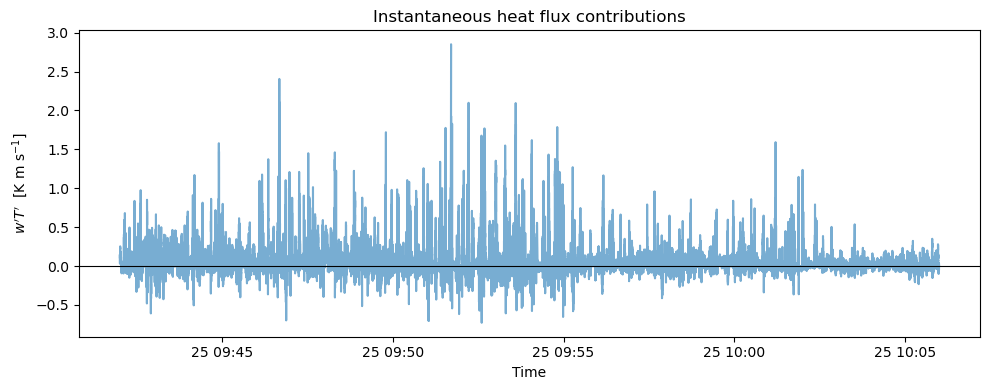

In [104]:
w_p = fluctuations(leg.w)
T_p = fluctuations(leg.t_air)

plt.figure(figsize=(10,4))
plt.plot(leg.time, w_p * T_p, alpha=0.6)
plt.axhline(0, color="k", lw=0.8)

plt.ylabel(r"$w'T'$  [K m s$^{-1}$]")
plt.xlabel("Time")
plt.title("Instantaneous heat flux contributions")
plt.tight_layout()
plt.show()


### Covariance spectrum

In [87]:
w_d = detrend(leg.w.values, type="linear")
T_d = detrend(leg.t_air.values, type="linear")

fs = 100  # Hz


In [107]:
fs = 100  # sampling frequency [Hz]

w_d = detrend(leg.w.values, type="linear")
T_d = detrend(leg.t_air.values, type="linear")


In [108]:
f, S_wT = csd(
    w_d,
    T_d,
    fs=fs,
    window="hann",
    nperseg=2048,
    noverlap=1024,
    detrend=False,
    scaling="density"
)


In [109]:
cospec = np.real(S_wT)


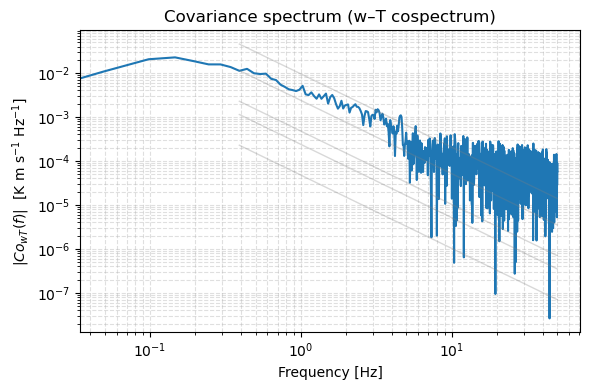

In [110]:
plt.figure(figsize=(6,4))
plt.loglog(f, f*np.abs(cospec), lw=1.5)
plt.axhline(0, color="k", lw=0.8)

# Vertical offsets for background lines
offsets = [0.001, 0.005, 0.01, 0.05, 0.2]

for fac in offsets:
    plt.loglog(
        f_ref,
        fac * P0 * (f_ref / f0) ** (-5/3),
        color="gray",
        alpha=0.3,
        linewidth=1
    )


#plt.xlim(0.2,50)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|Co_{wT}(f)|$  [K m s$^{-1}$ Hz$^{-1}$]")
plt.title("Covariance spectrum (w–T cospectrum)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [112]:
flux_from_spectrum = np.trapz(cospec, f)
print("Flux from cospectrum:", flux_from_spectrum)


Flux from cospectrum: 0.053476728874171625
